# OptiVest Methodology Integrity Case Study

This notebook presents the project's most important validation lesson: the original historical replay reused its estimation dates, the corrected static split enforced a clean temporal boundary, and monthly walk-forward re-estimation produced a still more demanding test. Curves and metrics come from the saved snapshot and latest persisted `walk_forward_runs` record, with the original replay reconstructed through the production backtest service.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import select, func, and_
from sqlalchemy.ext.asyncio import async_sessionmaker

REPO_ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "backend" / "app").is_dir()
)
BACKEND_ROOT = REPO_ROOT / "backend"
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))
os.chdir(BACKEND_ROOT)

from app.core.config import get_settings
from app.db.session import create_engine

SETTINGS = get_settings()
ENGINE = create_engine()
SessionLocal = async_sessionmaker(ENGINE, expire_on_commit=False, autoflush=False)

sns.set_theme(style="whitegrid", context="notebook")
OPTIVEST = {"navy": "#14213D", "teal": "#00A896", "gold": "#FCA311", "red": "#D1495B"}
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"Repository: {REPO_ROOT}")
print(f"Database configured by app.core.config: {SETTINGS.database_url.split('@')[-1]}")

Repository: P:\Placement\Projects\Github Projects\IT\OR-OptiVest
Database configured by app.core.config: localhost:5433/optivest


## Load the persisted validation evidence

The corrected static and walk-forward points are stored JSON results. The biased curve is reproducibly reconstructed from the persisted snapshot weights over the same dates because the application intentionally does not persist every analytics response.

In [2]:
from app.analytics.backtest import BacktestMode, RebalanceFrequency, run_backtest
from app.analytics.risk_metrics import maximum_drawdown, realized_annualized_return, realized_annualized_volatility, sharpe_ratio
from app.db.models import OptimizationRun, PortfolioHolding, PortfolioSnapshot, Stock, WalkForwardRun

async with SessionLocal() as session:
    stored_walk = await session.scalar(
        select(WalkForwardRun).order_by(WalkForwardRun.created_at.desc()).limit(1)
    )
    assert stored_walk is not None
    biased_snapshot = await session.scalar(
        select(PortfolioSnapshot)
        .where(PortfolioSnapshot.portfolio_id == stored_walk.portfolio_id)
        .order_by(PortfolioSnapshot.created_at.desc())
        .limit(1)
    )
    assert biased_snapshot is not None
    run = await session.get(OptimizationRun, biased_snapshot.optimization_run_id)
    holding_rows = (await session.execute(
        select(Stock.symbol, PortfolioHolding.weight)
        .join(Stock, Stock.id == PortfolioHolding.stock_id)
        .where(PortfolioHolding.snapshot_id == biased_snapshot.id)
        .order_by(Stock.symbol)
    )).all()
    biased_weights = {symbol: float(weight) for symbol, weight in holding_rows}
    biased_replay = await run_backtest(
        session,
        biased_weights,
        float(run.budget),
        stored_walk.start_date,
        stored_walk.end_date,
        BacktestMode.PERIODIC_REBALANCE,
        RebalanceFrequency.MONTHLY,
    )

stored = stored_walk.result
static_points = pd.DataFrame(stored["static_comparison"]["points"])
walk_points = pd.DataFrame(stored["walk_forward"]["points"])
biased_points = pd.DataFrame([
    {"trade_date": point.trade_date, "portfolio_value": point.portfolio_value, "portfolio_return": point.portfolio_return}
    for point in biased_replay.points
])
for frame in (static_points, walk_points, biased_points):
    frame["trade_date"] = pd.to_datetime(frame["trade_date"])
    frame["portfolio_value"] = frame["portfolio_value"].astype(float)
    frame["portfolio_return"] = frame["portfolio_return"].astype(float)

print(f"Persisted walk-forward run: {stored_walk.id}")
print(f"Evaluation: {stored_walk.start_date} to {stored_walk.end_date}; {len(static_points)} static observations; {len(walk_points)} walk-forward observations")
print(f"Biased snapshot: {biased_snapshot.id}; fit expected return {float(biased_snapshot.expected_return):.2%}; fit Sharpe {float(biased_snapshot.sharpe_ratio):.2f}")

Persisted walk-forward run: 211b3ed5-a04f-4e1b-958e-28dc82ea7eef
Evaluation: 2025-01-30 to 2026-01-30; 249 static observations; 249 walk-forward observations
Biased snapshot: 4cf1c32e-4f69-473a-8242-7d5974c3a269; fit expected return 43.04%; fit Sharpe 2.61


## Look-ahead bias: invalid replay vs clean static split

The invalid curve uses weights selected with all 249 evaluation dates already present in the fit window. The corrected curve uses weights estimated strictly before 2025-01-30. Their difference is evidence of methodological leakage, not a performance target.

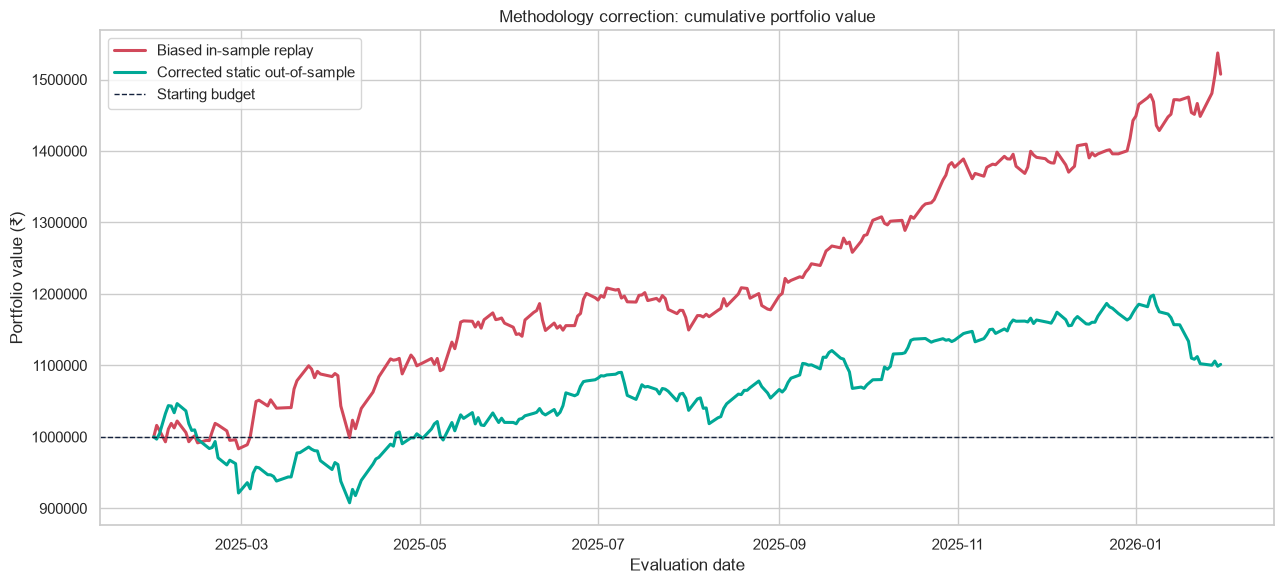

In [3]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(biased_points["trade_date"], biased_points["portfolio_value"], color=OPTIVEST["red"], linewidth=2.2, label="Biased in-sample replay")
ax.plot(static_points["trade_date"], static_points["portfolio_value"], color=OPTIVEST["teal"], linewidth=2.2, label="Corrected static out-of-sample")
ax.axhline(float(run.budget), color=OPTIVEST["navy"], linestyle="--", linewidth=1, label="Starting budget")
ax.set(title="Methodology correction: cumulative portfolio value", xlabel="Evaluation date", ylabel="Portfolio value (₹)")
ax.ticklabel_format(axis="y", style="plain")
ax.legend()
fig.tight_layout()
plt.show()

## Static split vs monthly walk-forward re-estimation

Both curves are out-of-sample. The static method holds the first pre-split fit, while walk-forward refits only with information available before each monthly decision date.

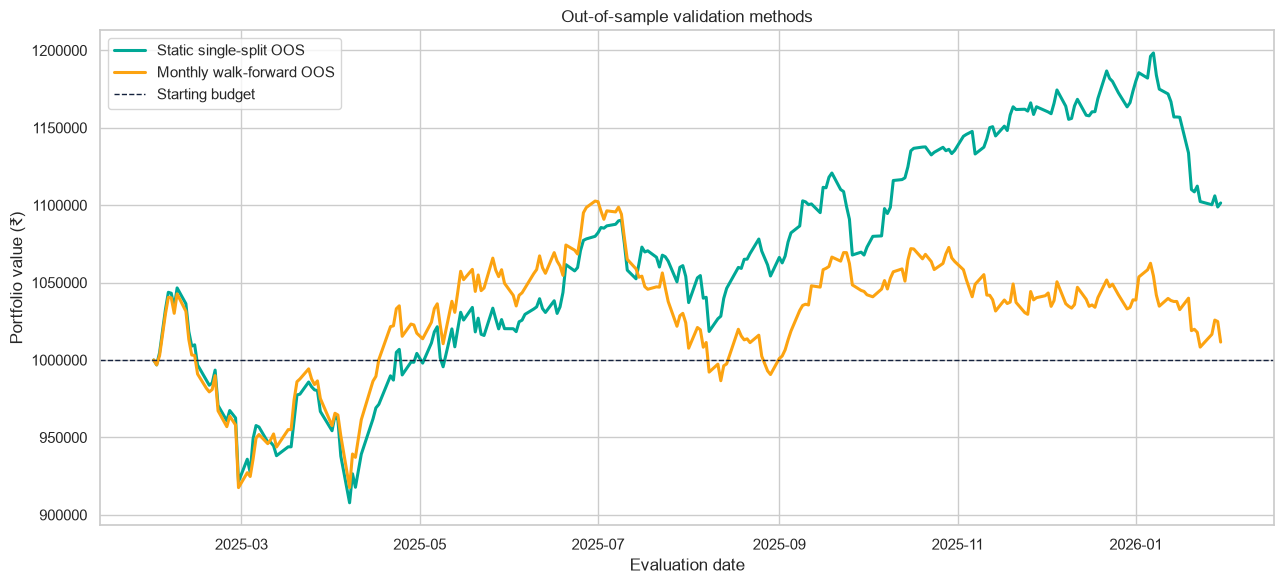

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(static_points["trade_date"], static_points["portfolio_value"], color=OPTIVEST["teal"], linewidth=2.2, label="Static single-split OOS")
ax.plot(walk_points["trade_date"], walk_points["portfolio_value"], color=OPTIVEST["gold"], linewidth=2.2, label="Monthly walk-forward OOS")
ax.axhline(float(run.budget), color=OPTIVEST["navy"], linestyle="--", linewidth=1, label="Starting budget")
ax.set(title="Out-of-sample validation methods", xlabel="Evaluation date", ylabel="Portfolio value (₹)")
ax.ticklabel_format(axis="y", style="plain")
ax.legend()
fig.tight_layout()
plt.show()

## Three-way realized metrics

To keep the rows comparable, the biased replay metrics below are computed from its realized daily return series with the production risk-metric functions. The snapshot's 43.04% expected return and 2.61 model Sharpe are fit-period estimates and are reported separately above rather than mixed into realized columns.

In [5]:
risk_free_rate = float(stored_walk.constraints_snapshot.get("risk_free_rate", 0.0))
biased_return = realized_annualized_return(biased_replay.returns)
biased_volatility = realized_annualized_volatility(biased_replay.returns)
biased_metrics = {
    "annualized_return": biased_return,
    "annualized_volatility": biased_volatility,
    "sharpe_ratio": sharpe_ratio(biased_return, risk_free_rate, biased_volatility),
    "max_drawdown": maximum_drawdown(biased_replay.values),
    "final_value_inr": float(biased_replay.values[-1]),
}
static_metrics = {key: float(value) for key, value in stored["static_comparison"]["metrics"].items()}
walk_metrics = {key: float(value) for key, value in stored["walk_forward"]["metrics"].items()}
metrics_df = pd.DataFrame([
    {"method": "Biased in-sample replay", **biased_metrics},
    {"method": "Static out-of-sample", **static_metrics},
    {"method": "Walk-forward out-of-sample", **walk_metrics},
])[["method", "annualized_return", "sharpe_ratio", "max_drawdown", "annualized_volatility", "final_value_inr"]]
display(metrics_df.style.format({
    "annualized_return": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "final_value_inr": "₹{:,.2f}",
}))

,method,annualized_return,sharpe_ratio,max_drawdown,annualized_volatility,final_value_inr
0,Biased in-sample replay,51.49%,3.12,-9.15%,16.50%,"₹1,507,469.92"
1,Static out-of-sample,10.27%,0.68,-13.26%,15.19%,"₹1,101,423.96"
2,Walk-forward out-of-sample,1.17%,0.08,-12.00%,15.23%,"₹1,011,596.09"


## Interpretation

The first replay looked exceptional because selection and evaluation shared the same 249 trading dates; it was descriptive of the fitted sample, not evidence of future performance. Enforcing a strict split reduced the result to a credible but much more modest out-of-sample outcome. Monthly walk-forward refitting then finished close to the starting value: the stored period audit shows that this was not a compounding or missing-data bug, but a result concentrated in several difficult regimes and amplified by unstable recent-mean estimates. More frequent updating therefore did not automatically improve the decision. The honest conclusion is that temporal separation is mandatory, and that estimation noise and turnover must be treated as first-class model risks.

In [6]:
await ENGINE.dispose()
print("Database engine disposed; persisted evidence was read without modification.")

Database engine disposed; persisted evidence was read without modification.


## Key takeaway

Methodological integrity changed the project's conclusion in a useful way: the corrected system no longer presents a leaked backtest as validation, and the walk-forward result demonstrates why realistic portfolio research must report weaker evidence honestly rather than tune it away.